In [ ]:
# !pip install pandas numpy textblob scikit-learn

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import glob
import os
# 1. 데이터 로드
data_dir = "/content/drive/MyDrive/Colab Notebooks"
metro_map = [
    "서울","부산","대구","인천","광주","대전",
    "울산","세종","경기","강원","충북","충남",
    "전북","전남","경북","경남","제주"
]
files = glob.glob(os.path.join(data_dir, "*_filtered.csv"))

In [ ]:
print("검색된 파일 목록:", files)

검색된 파일 목록: ['/content/drive/MyDrive/Colab Notebooks/세종_filtered.csv', '/content/drive/MyDrive/Colab Notebooks/광주_filtered.csv', '/content/drive/MyDrive/Colab Notebooks/인천_filtered.csv', '/content/drive/MyDrive/Colab Notebooks/대구_filtered.csv', '/content/drive/MyDrive/Colab Notebooks/대전_filtered.csv', '/content/drive/MyDrive/Colab Notebooks/충북_filtered.csv', '/content/drive/MyDrive/Colab Notebooks/울산_filtered.csv', '/content/drive/MyDrive/Colab Notebooks/경남_filtered.csv', '/content/drive/MyDrive/Colab Notebooks/충남_filtered.csv', '/content/drive/MyDrive/Colab Notebooks/강원도_filtered.csv', '/content/drive/MyDrive/Colab Notebooks/서울_filtered.csv']


In [ ]:
# ========== 0) Colab Drive 마운트 ==========
from google.colab import drive
drive.mount('/content/drive')

# ========== 1) 설정 ==========
import os, glob, unicodedata
import pandas as pd
from transformers import pipeline
import torch

# 데이터 폴더(Drive)
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks"

# 체크포인트/결과 저장 폴더(Drive)
SAVE_DIR = os.path.join(DATA_DIR, "_ckpt")  # <- 드라이브 안에 명시적으로 저장
os.makedirs(SAVE_DIR, exist_ok=True)

CKPT_PRED_FILE    = os.path.join(SAVE_DIR, "sentiment_ckpt_byfile.csv")  # 배치 예측 저장
STORE_SCORES_FILE = os.path.join(SAVE_DIR, "store_scores.csv")           # 최종 매장 점수
BATCH_SIZE        = 32
COUNT_BASE        = 50  # count 정규화 기준

# 지역 목록(NFC)
METRO_MAP = ["서울","부산","대구","인천","광주","대전","울산","세종","경기",
             "강원","충북","충남","전북","전남","경북","경남","제주"]
NFC_METRO = {unicodedata.normalize("NFC", m): m for m in METRO_MAP}

print(f"[INFO] DATA_DIR={DATA_DIR}")
print(f"[INFO] SAVE_DIR={SAVE_DIR}")
print(f"[INFO] CKPT_PRED_FILE={CKPT_PRED_FILE}")
print(f"[INFO] STORE_SCORES_FILE={STORE_SCORES_FILE}")

# ========== 2) 유틸 ==========
def list_region_files():
    """DATA_DIR에 있는 *_filtered.csv 중 지역명 매칭되는 파일만 반환."""
    files = glob.glob(os.path.join(DATA_DIR, "*_filtered.csv"))
    items = []
    for f in files:
        name = os.path.basename(f).replace("_filtered.csv", "")
        n_name = unicodedata.normalize("NFC", name)
        if n_name in NFC_METRO:
            items.append((f, NFC_METRO[n_name]))  # (path, region)
    return items

def load_ckpt():
    if os.path.exists(CKPT_PRED_FILE):
        return pd.read_csv(CKPT_PRED_FILE)
    return pd.DataFrame(columns=["source_file","row_id","sentiment_score","class_prob"])

def append_ckpt(df_rows: pd.DataFrame):
    """체크포인트 파일에 배치 예측 결과를 즉시 append."""
    if df_rows is None or df_rows.empty:
        return
    header = not os.path.exists(CKPT_PRED_FILE)
    df_rows.to_csv(CKPT_PRED_FILE, mode="a", header=header, index=False)
    # 확인용 로그
    try:
        size = os.path.getsize(CKPT_PRED_FILE)
        print(f"[CKPT] wrote {len(df_rows)} rows -> {CKPT_PRED_FILE} (size={size} bytes)")
    except Exception as e:
        print("[CKPT] size check failed:", e)

def build_pipeline():
    device = 0 if torch.cuda.is_available() else -1
    print(f"[INFO] torch.cuda.is_available()={torch.cuda.is_available()} -> device={device}")
    return pipeline(
        "sentiment-analysis",
        model="nlptown/bert-base-multilingual-uncased-sentiment",
        device=device,
        batch_size=BATCH_SIZE,
        truncation=True
    )

# ========== 3) 새로 추가된 파일만 예측 (체크포인트 생성/추가) ==========
def run_predictions_on_new_files():
    """
    체크포인트(파일별 row_id 기준)를 활용해
    이미 처리한 행은 건너뛰고, 부족한 행만 이어서 예측합니다.
    """
    ckpt = load_ckpt()
    region_files = list_region_files()
    if not region_files:
        raise FileNotFoundError(f"No *_filtered.csv in {DATA_DIR}")

    pipe = build_pipeline()
    processed_regions = []

    for fpath, region in region_files:
        bname = os.path.basename(fpath)
        print(f"[RUN] {bname} ({region})")

        df = pd.read_csv(fpath)
        if "review_text" not in df.columns:
            print(" - Warning: review_text 없음 → skip")
            continue

        df = df.reset_index(drop=True)
        n = len(df)

        # 이 파일에서 이미 처리된 row_id 집합
        done_rows = set(
            ckpt.loc[ckpt["source_file"] == bname, "row_id"].astype(int).tolist()
        )
        # 아직 안 한 인덱스만 대상
        todo_idx = [i for i in range(n) if i not in done_rows]

        if not todo_idx:
            print(" - 이미 완료된 파일 → skip")
            continue

        # 배치 예측 + 즉시 append (중간 중단 대비)
        for start in range(0, len(todo_idx), BATCH_SIZE):
            idx_batch = todo_idx[start:start + BATCH_SIZE]
            batch_texts = df.loc[idx_batch, "review_text"].astype(str).tolist()
            outs = pipe(batch_texts)

            rows = []
            for i_orig, out in zip(idx_batch, outs):
                # '4 stars' 또는 '1 star' 형태 대응
                label = out.get("label", "")
                try:
                    star = int(label.split()[0])
                except Exception:
                    star = int(str(label)[:1])  # 폴백
                sent = (star - 1) / 4.0  # 0~1 스케일
                prob = float(out.get("score", 0.0))
                rows.append([bname, i_orig, sent, prob])

            append_ckpt(pd.DataFrame(
                rows, columns=["source_file","row_id","sentiment_score","class_prob"]
            ))

        processed_regions.append(region)

    return processed_regions

# ========== 4) 점수 집계 ==========
def build_scores_for_regions(target_regions=None):
    """체크포인트와 원본을 합쳐 (region, store_name, address)별 점수 산출."""
    ckpt = load_ckpt()
    if ckpt.empty:
        raise RuntimeError("체크포인트가 비어 있습니다. 먼저 예측을 실행하세요.")

    region_files = list_region_files()
    parts = []
    for fpath, region in region_files:
        if target_regions is not None and region not in target_regions:
            continue
        bname = os.path.basename(fpath)
        df = pd.read_csv(fpath).reset_index().rename(columns={"index":"row_id"})
        df["source_file"] = bname
        keep = ["source_file","row_id","store_name","address"]
        if "review_text" in df.columns:  # 있으면 유지
            keep.append("review_text")
        df = df[keep]
        merged = df.merge(ckpt, on=["source_file","row_id"], how="inner")
        if merged.empty:
            print(f"[WARN] {bname} merge 결과 없음(체크포인트 부족)")
            continue
        merged["region"] = region
        parts.append(merged)

    if not parts:
        raise RuntimeError("병합 결과가 없습니다. target_regions를 확인하세요.")
    combined = pd.concat(parts, ignore_index=True)

    combined["count"] = 1
    agg = combined.groupby(["region","store_name","address"], dropna=False).agg(
        count          = ("count","sum"),
        avg_sentiment  = ("sentiment_score","mean"),
        avg_class_prob = ("class_prob","mean"),
    ).reset_index()

    agg["count_norm"]   = (agg["count"] / COUNT_BASE).clip(0, 1)
    agg["review_score"] = agg[["count_norm","avg_sentiment","avg_class_prob"]].mean(axis=1)
    return agg

# ========== 5) 기존 점수 파일에 새 지역만 갱신 병합 (반환 추가) ==========
def update_store_scores(new_regions, return_df=False):
    """
    새 지역이 없더라도 체크포인트가 있으면 전체 재집계하여 store_scores.csv를 생성/갱신.
    기존 파일이 있으면 해당 지역만 교체, 없으면 전체 생성.
    """
    ckpt = load_ckpt()
    if ckpt.empty:
        print("[INFO] 체크포인트가 비어 있습니다. 먼저 예측을 실행하세요.")
        if return_df and os.path.exists(STORE_SCORES_FILE):
            return pd.read_csv(STORE_SCORES_FILE)
        return None

    # 새 지역이 없으면 전체 재집계
    if not new_regions:
        print("[INFO] 새 지역 없음 → 체크포인트 기반 전체 재집계.")
        rebuilt = build_scores_for_regions(target_regions=None)  # 모든 지역
        rebuilt.to_csv(STORE_SCORES_FILE, index=False)
        print(f"[DONE] {STORE_SCORES_FILE} 재생성 (regions={sorted(rebuilt['region'].unique())})")
        return rebuilt if return_df else None

    # 새 지역이 있으면 부분 갱신
    new_scores = build_scores_for_regions(target_regions=new_regions)

    if os.path.exists(STORE_SCORES_FILE):
        old = pd.read_csv(STORE_SCORES_FILE)
        updated = pd.concat([
            old[~old["region"].isin(new_scores["region"].unique())],
            new_scores
        ], ignore_index=True)
    else:
        updated = new_scores

    updated.to_csv(STORE_SCORES_FILE, index=False)
    print(f"[DONE] {STORE_SCORES_FILE} 갱신 (regions={sorted(set(new_regions))})")

    if return_df:
        return updated

# ========== 6) 실행 & 최종 DF 확인 ==========
processed_regions = run_predictions_on_new_files()   # 새 파일만 예측 수행
updated = update_store_scores(processed_regions, return_df=True)

# 항상 df_final을 만들기
if isinstance(updated, pd.DataFrame) and not updated.empty:
    df_final = updated.copy()
elif os.path.exists(STORE_SCORES_FILE):
    df_final = pd.read_csv(STORE_SCORES_FILE)
else:
    # 여기까지 왔는데 파일도 없으면 데이터가 없는 상황
    df_final = pd.DataFrame()
    print("store_scores.csv가 아직 존재하지 않거나 데이터가 비어 있습니다.")

print("\n[RESULT] 최종 store_scores 샘플 (상위 20):")
if not df_final.empty:
    print(df_final.sort_values(["region","review_score"], ascending=[True,False]).head(20).to_string(index=False))
else:
    print("표시할 데이터가 없습니다. 체크포인트와 원본 CSV를 확인하세요.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[INFO] DATA_DIR=/content/drive/MyDrive/Colab Notebooks
[INFO] SAVE_DIR=/content/drive/MyDrive/Colab Notebooks/_ckpt
[INFO] CKPT_PRED_FILE=/content/drive/MyDrive/Colab Notebooks/_ckpt/sentiment_ckpt_byfile.csv
[INFO] STORE_SCORES_FILE=/content/drive/MyDrive/Colab Notebooks/_ckpt/store_scores.csv
[INFO] torch.cuda.is_available()=True -> device=0


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


[RUN] 세종_filtered.csv (세종)
 - 이미 완료된 파일 → skip
[RUN] 광주_filtered.csv (광주)
 - 이미 완료된 파일 → skip
[RUN] 인천_filtered.csv (인천)
 - 이미 완료된 파일 → skip
[RUN] 대구_filtered.csv (대구)
 - 이미 완료된 파일 → skip
[RUN] 대전_filtered.csv (대전)
 - 이미 완료된 파일 → skip
[RUN] 충북_filtered.csv (충북)
 - 이미 완료된 파일 → skip
[RUN] 울산_filtered.csv (울산)
 - 이미 완료된 파일 → skip
[RUN] 경남_filtered.csv (경남)
 - 이미 완료된 파일 → skip
[RUN] 충남_filtered.csv (충남)
 - 이미 완료된 파일 → skip
[RUN] 서울_filtered.csv (서울)
 - 이미 완료된 파일 → skip
[INFO] 새 지역 없음 → 체크포인트 기반 전체 재집계.
[DONE] /content/drive/MyDrive/Colab Notebooks/_ckpt/store_scores.csv 재생성 (regions=['경남', '광주', '대구', '대전', '서울', '세종', '울산', '인천', '충남', '충북'])

[RESULT] 최종 store_scores 샘플 (상위 20):
region       store_name               address  count  avg_sentiment  avg_class_prob  count_norm  review_score
    경남            지세포 숨                  경상남도     47       0.750000        0.345745        0.94      0.678582
    경남             초아수산                  경상남도     48       0

In [ ]:
df_final.head(20)

,region,store_name,address,count,avg_sentiment,avg_class_prob,count_norm,review_score
0,경남,(사) 국가무형유산 고성오광대보존회,경상남도,13,0.826923,0.369689,0.26,0.485538
1,경남,123할매김밥,경상남도 (서호동),3,0.000000,0.353168,0.06,0.137723
2,경남,1919봄,경상남도,43,0.476744,0.298312,0.86,0.545019
3,경남,1971카페,경상남도,33,0.409091,0.298402,0.66,0.455831
4,경남,1997영국집,경상남도,47,0.510638,0.301276,0.94,0.583972
5,경남,2024 밀양강오딧세이 “별들의 노래”,경상남도 244-2,1,0.250000,0.276140,0.02,0.182047
6,경남,2024 진주 세계민속예술 비엔날레,경상남도 245-239,20,0.712500,0.337877,0.40,0.483459
7,경남,2025 국민고향 남해 마시고 RUN,경상남도,17,0.514706,0.314186,0.34,0.389631
8,경남,224커피,경상남도,45,0.405556,0.302042,0.90,0.535866
9,경남,24시 남양돼지국밥,경상남도,46,0.396739,0.297731,0.92,0.538157


In [ ]:
import sys

# Google Colab 환경에서 실행 중인지 확인
if 'google.colab' in sys.modules:
    # debconf를 Noninteractive 모드로 설정
    !echo 'debconf debconf/frontend select Noninteractive' | \
    debconf-set-selections

    # fonts-nanum 패키지를 설치
    !sudo apt-get -qq -y install fonts-nanum

    # Matplotlib의 폰트 매니저 가져오기
    import matplotlib.font_manager as fm

    # 나눔 폰트의 시스템 경로 찾기
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])

    # 찾은 각 나눔 폰트를 Matplotlib 폰트 매니저에 추가
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

In [ ]:
# === 0) Colab 한글 폰트 세팅 ===
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

!apt-get update -qq
!apt-get install -y fonts-nanum fonts-nanum-extra fonts-nanum-coding fonts-noto-cjk >/dev/null

import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import shutil

shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)
fm._load_fontmanager(try_read_cache=False)

candidates = ["NanumBarunGothic", "NanumGothic", "Noto Sans CJK KR"]
avail = {n: any(n in f.name for f in fm.fontManager.ttflist) for n in candidates}
chosen = next((n for n in candidates if avail.get(n)), "DejaVu Sans")

plt.rcParams["font.family"] = [chosen]
plt.rcParams["axes.unicode_minus"] = False
print("Using font:", chosen)


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


Using font: NanumBarunGothic


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


Using font: NanumBarunGothic


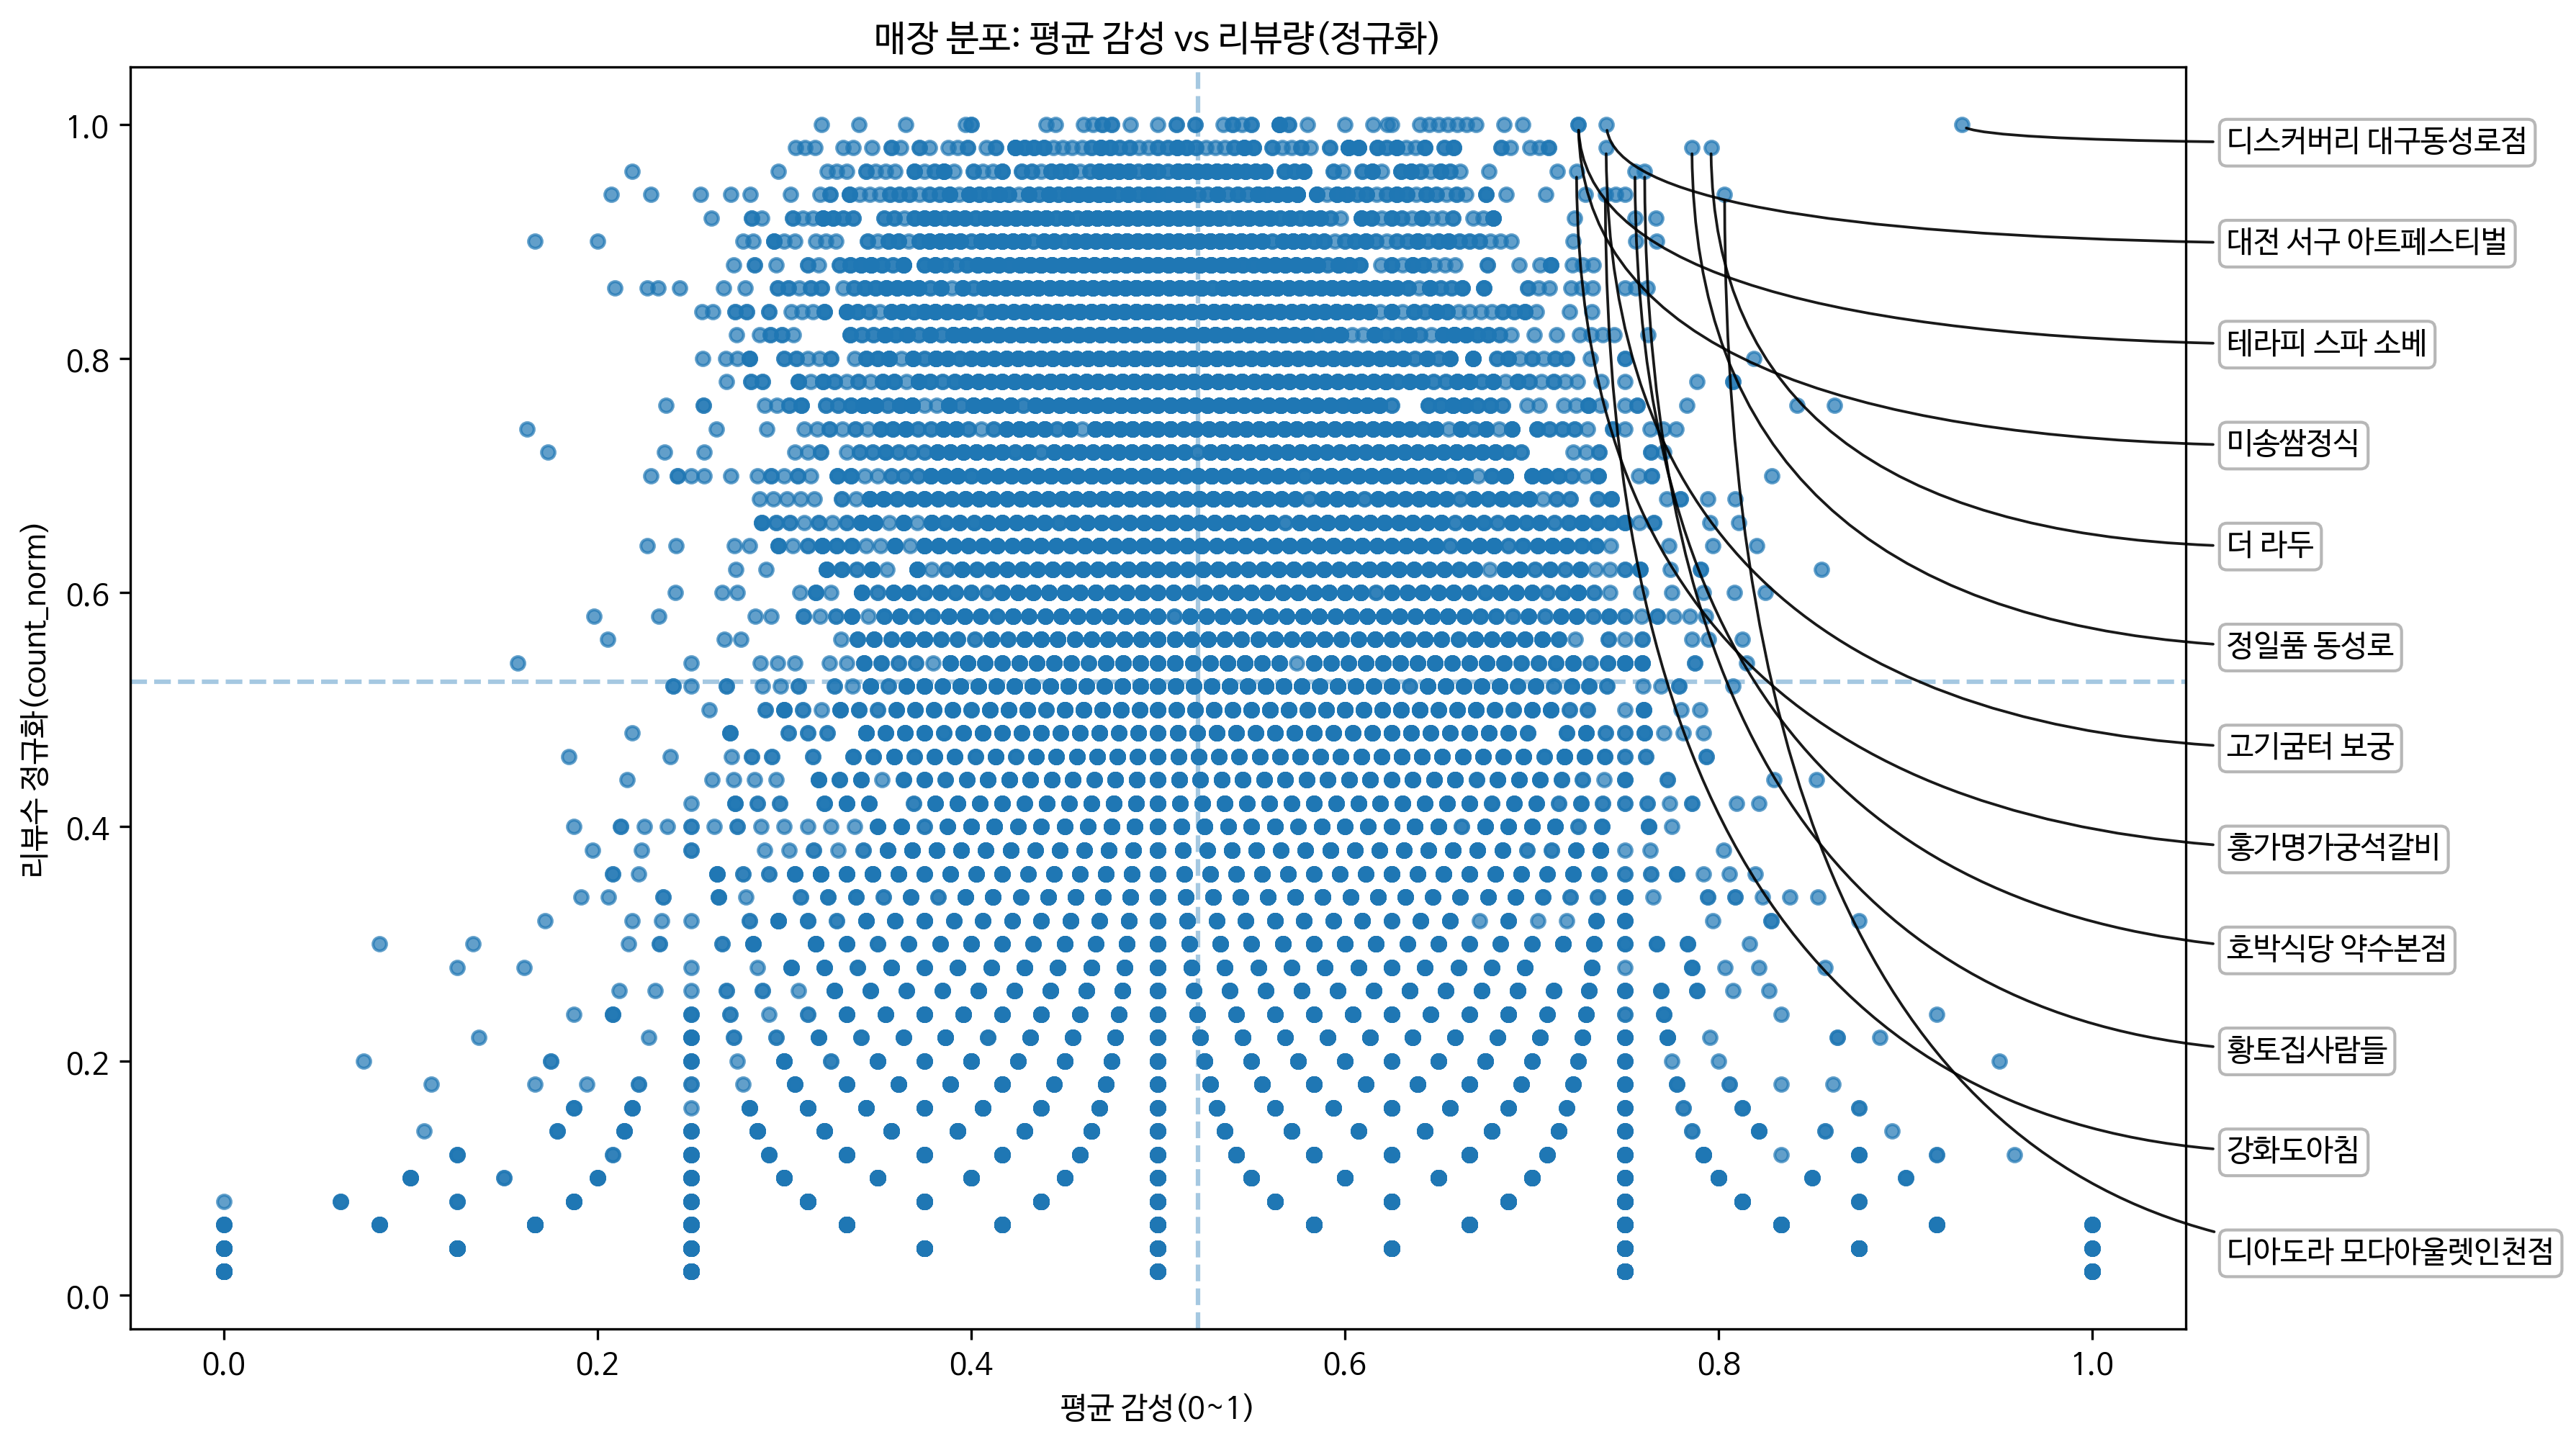

In [ ]:
# ================================
# 0) Colab 한글 폰트 세팅 (1회)
# ================================
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

!apt-get update -qq
!apt-get install -y fonts-nanum fonts-nanum-extra fonts-nanum-coding fonts-noto-cjk >/dev/null

import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import shutil

shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)
fm._load_fontmanager(try_read_cache=False)

candidates = ["NanumBarunGothic", "NanumGothic", "Noto Sans CJK KR"]
avail = {n: any(n in f.name for f in fm.fontManager.ttflist) for n in candidates}
chosen = next((n for n in candidates if avail.get(n)), "DejaVu Sans")

plt.rcParams["font.family"] = [chosen]
plt.rcParams["axes.unicode_minus"] = False
print("Using font:", chosen)


# =========================================
# 1) 라벨러: 오른쪽 세로열 + ㄱ자(엘보) 커넥터
# =========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _ellipsis(txt, n=16):
    txt = str(txt)
    return txt if len(txt) <= n else txt[:n-1] + "…"

def place_right_column_labels(ax, top_df,
                              x_col="avg_sentiment", y_col="count_norm",
                              label_col="store_name",
                              col_x=1.02,            # 라벨 열 x 위치(axes fraction)
                              top=0.92, bottom=0.08, # 라벨 열 세로 범위
                              fontsize=10, box=True):
    """
    그래프 오른쪽 바깥에 라벨을 '한 줄'로 세우고, 각 점과 ㄱ자 선으로 연결.
    """
    df = top_df.sort_values(y_col).reset_index(drop=True)
    n = len(df)
    # 균등 간격 세로 좌표(축 비율)
    ys = np.linspace(bottom, top, max(n, 2))[:n]

    for i, r in df.iterrows():
        ax.annotate(
            _ellipsis(r[label_col], 16),
            xy=(r[x_col], r[y_col]),              # 점의 실제 위치
            xycoords="data",
            xytext=(col_x, ys[i]),                # 라벨 위치(축 비율)
            textcoords="axes fraction",
            ha="left", va="center",
            fontsize=fontsize,
            bbox=(dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", alpha=0.95) if box else None),
            arrowprops=dict(
                arrowstyle="-", lw=0.9, alpha=0.9,
                connectionstyle="angle3,angleA=0,angleB=90"  # ㄱ자(엘보)
            ),
            clip_on=False, annotation_clip=False
        )


# ===================================================
# 2) 산포도 + 오른쪽 세로열 라벨 전체 함수 (호출만 하면 됨)
# ===================================================
def plot_store_scatter_with_right_labels(
    df_final,
    top_n=12,
    x_col="avg_sentiment",
    y_col="count_norm",
    label_col="store_name",
    score_col="review_score",
    figsize=(12, 6.8),
    dpi=150,
    right_margin=0.78,   # 오른쪽 여백 확보
    col_x=1.02,          # 라벨 열 x 위치
    col_top=0.92, col_bottom=0.08,
):
    # ---- 검증 & 전처리 ----
    need = [x_col, y_col, label_col, score_col]
    missing = [c for c in need if c not in df_final.columns]
    if missing:
        raise ValueError(f"필수 컬럼 누락: {missing}")

    df_scatter = df_final.dropna(subset=[x_col, y_col]).copy()
    # 안전 범위 클립
    df_scatter[x_col] = df_scatter[x_col].clip(0, 1)
    df_scatter[y_col] = df_scatter[y_col].clip(0, 1)

    # 라벨링 대상(상위 top_n)
    top = (df_scatter
           .sort_values(score_col, ascending=False)
           .drop_duplicates(subset=[label_col])  # 같은 이름 중복 방지
           .head(top_n))

    # ---- 플롯 ----
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.scatter(df_scatter[x_col], df_scatter[y_col], s=20, alpha=0.7)

    # 기준선(평균)
    ax.axvline(df_scatter[x_col].mean(), linestyle="--", alpha=0.4)
    ax.axhline(df_scatter[y_col].mean(), linestyle="--", alpha=0.4)

    ax.set_xlabel("평균 감성(0~1)")
    ax.set_ylabel("리뷰수 정규화(count_norm)")
    ax.set_title("매장 분포: 평균 감성 vs 리뷰량(정규화)")

    # 라벨 세우기 위한 공간 확보 + 배치
    plt.subplots_adjust(right=right_margin)
    place_right_column_labels(
        ax, top,
        x_col=x_col, y_col=y_col, label_col=label_col,
        col_x=col_x, top=col_top, bottom=col_bottom,
        fontsize=10, box=True
    )

    plt.tight_layout()
    plt.show()
    return fig


# ================================
# 3) 호출 예시 (그대로 실행)
# ================================
# 전제: df_final 이 준비되어 있어야 합니다.
# df_final.head()

# 상위 12개 라벨, 라벨 열 세로 범위 살짝 넓게
_ = plot_store_scatter_with_right_labels(
    df_final,
    top_n=12,
    figsize=(12, 6.8),
    dpi=150,
    right_margin=0.78,   # 라벨 공간
    col_x=1.02,          # 라벨 열 x 위치
    col_top=0.94, col_bottom=0.06
)


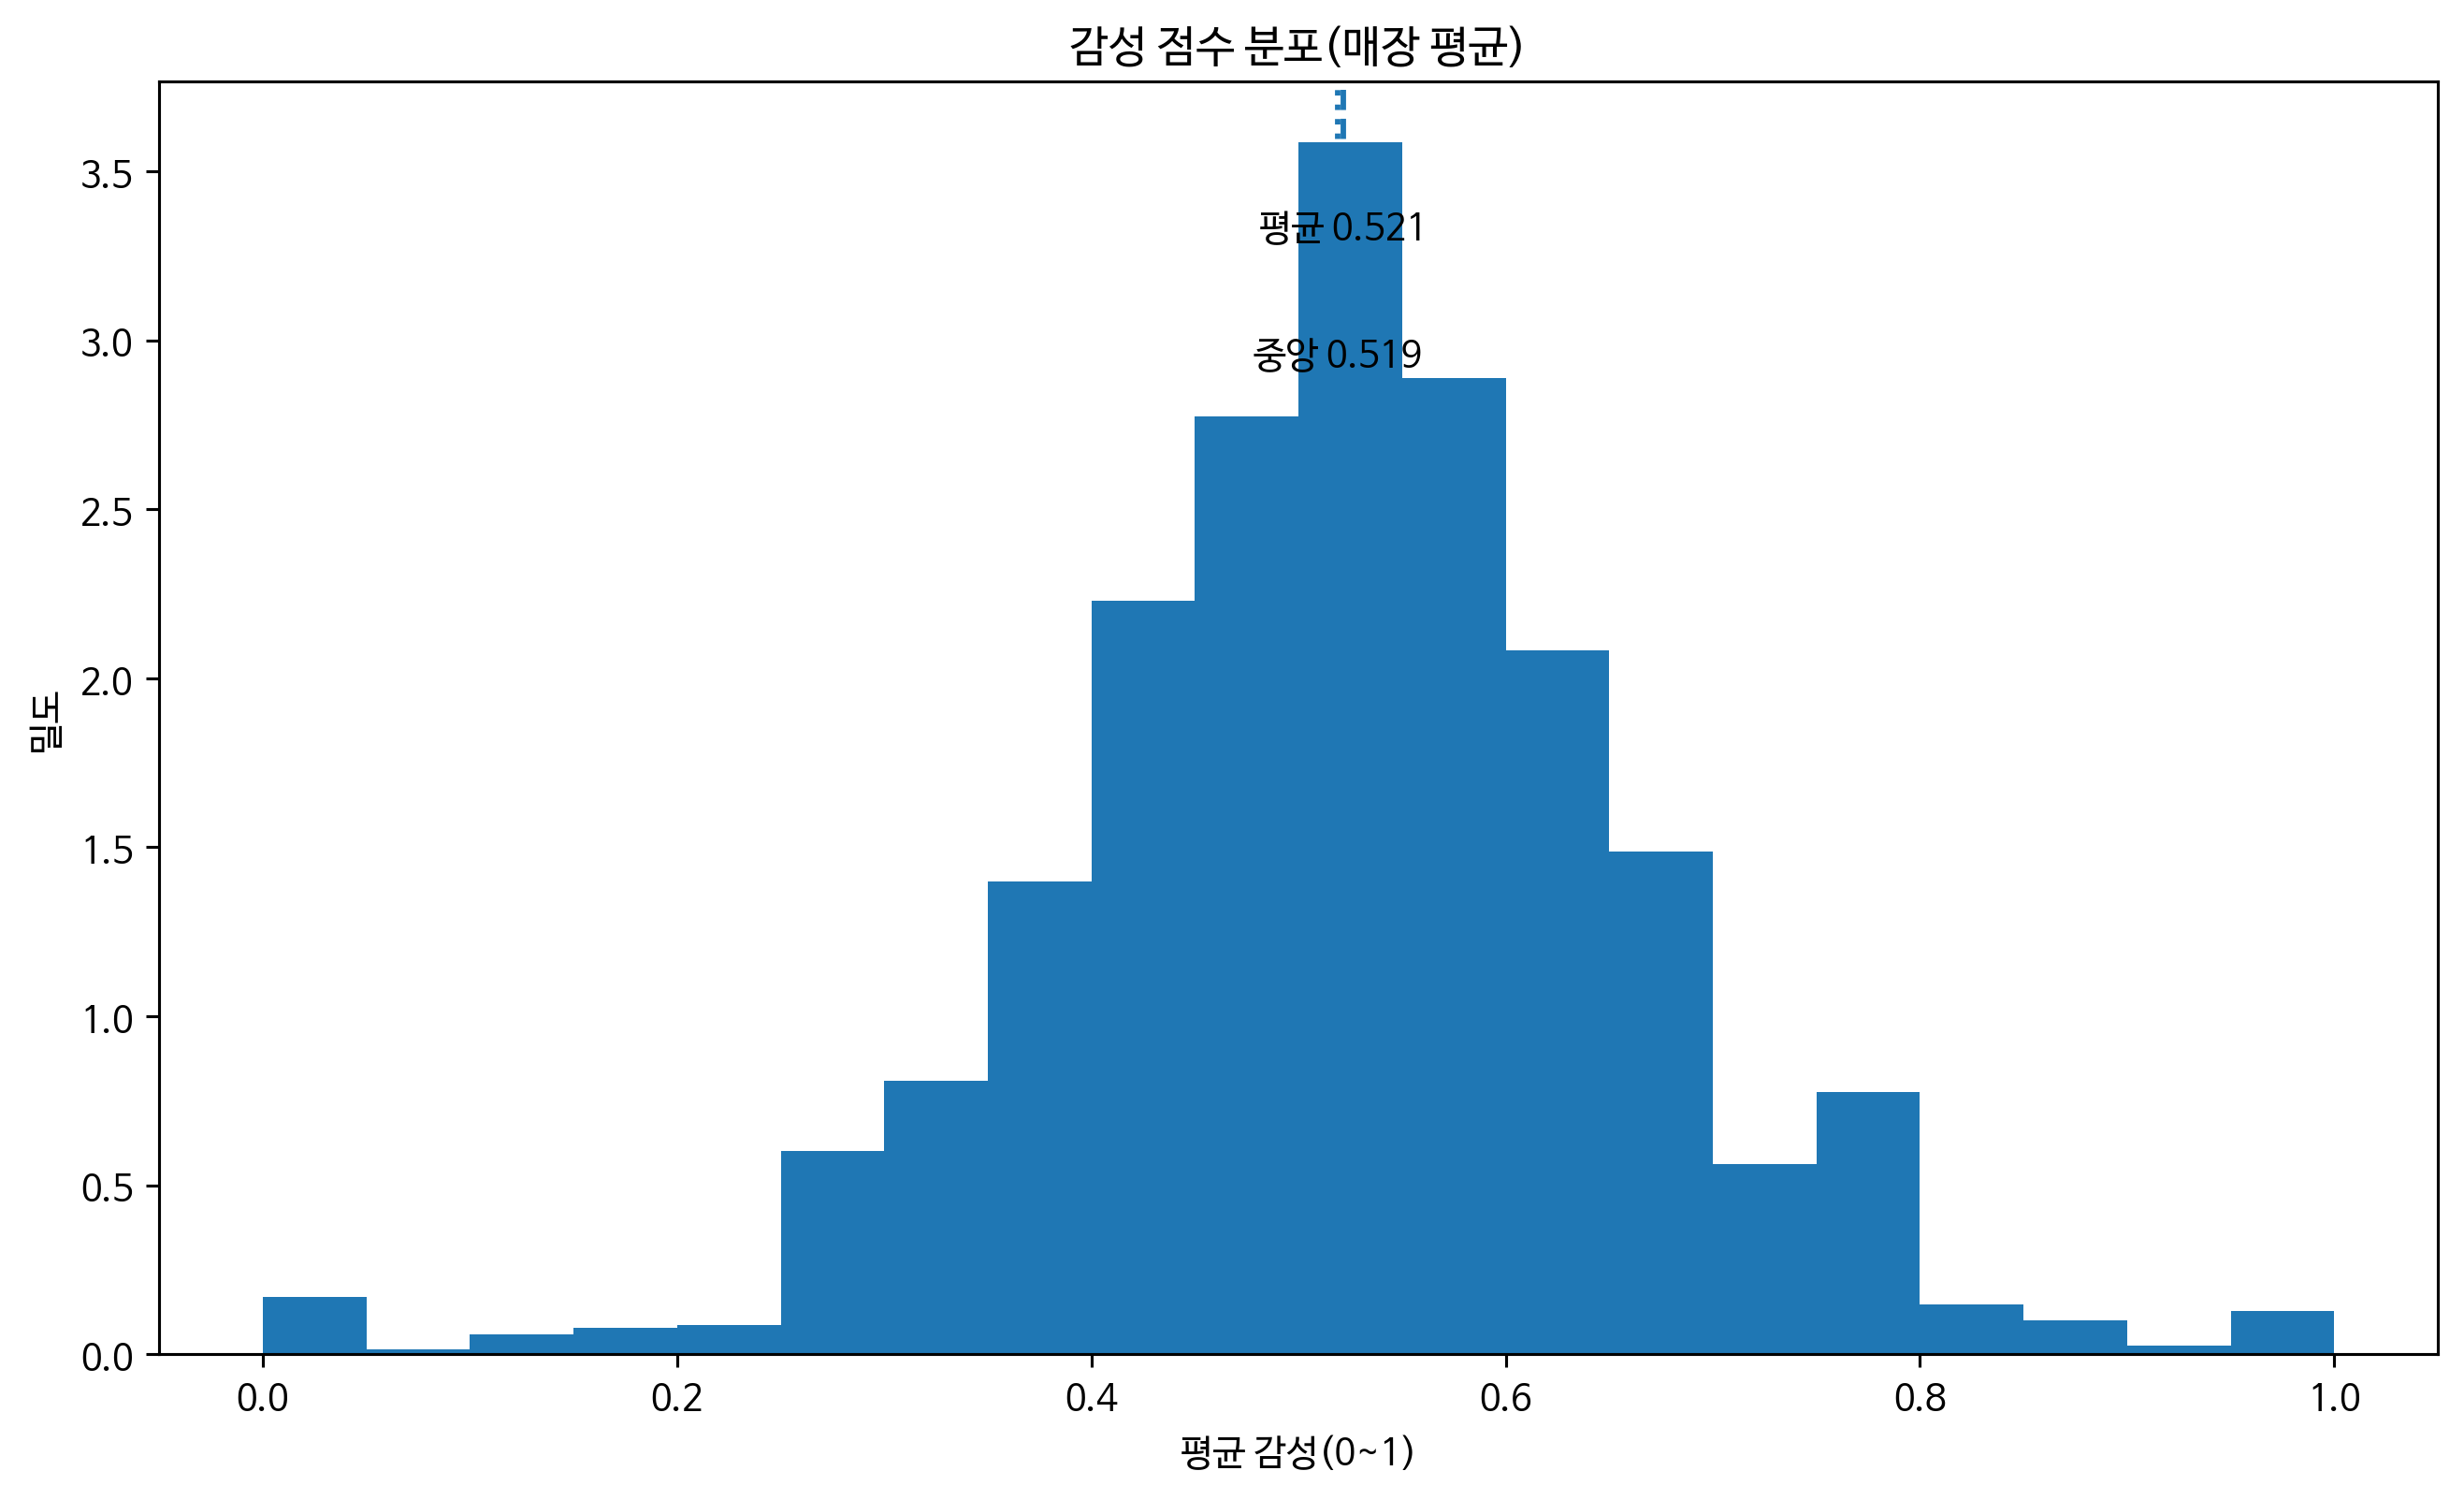

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

scores = df_final["avg_sentiment"].dropna().clip(0,1).to_numpy()
m, med = float(np.mean(scores)), float(np.median(scores))

fig, ax = plt.subplots(figsize=(9.5,5.8), dpi=140)
ax.hist(scores, bins=20, density=True)
ax.set_xlabel("평균 감성(0~1)"); ax.set_ylabel("밀도")
ax.set_title("감성 점수 분포(매장 평균)")

ax.axvline(m, linestyle="--"); ax.text(m, ax.get_ylim()[1]*0.9, f"평균 {m:.3f}", ha="center", va="top")
ax.axvline(med, linestyle=":"); ax.text(med, ax.get_ylim()[1]*0.8, f"중앙 {med:.3f}", ha="center", va="top")

plt.tight_layout(); plt.show()


In [ ]:
# === 1) 공통 설정 & 유틸 ===
import os, glob, unicodedata, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 드라이브 마운트(이미 마운트했다면 생략 가능)
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# 경로
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks"
SAVE_DIR = os.path.join(DATA_DIR, "_ckpt")
CKPT_PRED_FILE    = os.path.join(SAVE_DIR, "sentiment_ckpt_byfile.csv")
STORE_SCORES_FILE = os.path.join(SAVE_DIR, "store_scores.csv")

os.makedirs(SAVE_DIR, exist_ok=True)
print(f"[INFO] DATA_DIR={DATA_DIR}")
print(f"[INFO] SAVE_DIR={SAVE_DIR}")

# 지역 파일 찾기
def list_region_csvs():
    files = glob.glob(os.path.join(DATA_DIR, "*_filtered.csv"))
    return sorted(files)

def safe_read_csv(path, **kw):
    try:
        return pd.read_csv(path, **kw)
    except Exception as e:
        print(f"[WARN] read_csv 실패: {path} -> {e}")
        return pd.DataFrame()

# 로드
ckpt = safe_read_csv(CKPT_PRED_FILE)
stores = safe_read_csv(STORE_SCORES_FILE)

print("[INFO] ckpt shape:", ckpt.shape, "columns:", list(ckpt.columns))
print("[INFO] stores shape:", stores.shape, "columns:", list(stores.columns))

assert not ckpt.empty, "체크포인트가 비어 있습니다. 먼저 예측을 실행하세요."
assert not stores.empty, "store_scores.csv가 비어 있습니다. update_store_scores 이후 실행하세요."


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[INFO] DATA_DIR=/content/drive/MyDrive/Colab Notebooks
[INFO] SAVE_DIR=/content/drive/MyDrive/Colab Notebooks/_ckpt
[INFO] ckpt shape: (384964, 4) columns: ['source_file', 'row_id', 'sentiment_score', 'class_prob']
[INFO] stores shape: (14687, 8) columns: ['region', 'store_name', 'address', 'count', 'avg_sentiment', 'avg_class_prob', 'count_norm', 'review_score']


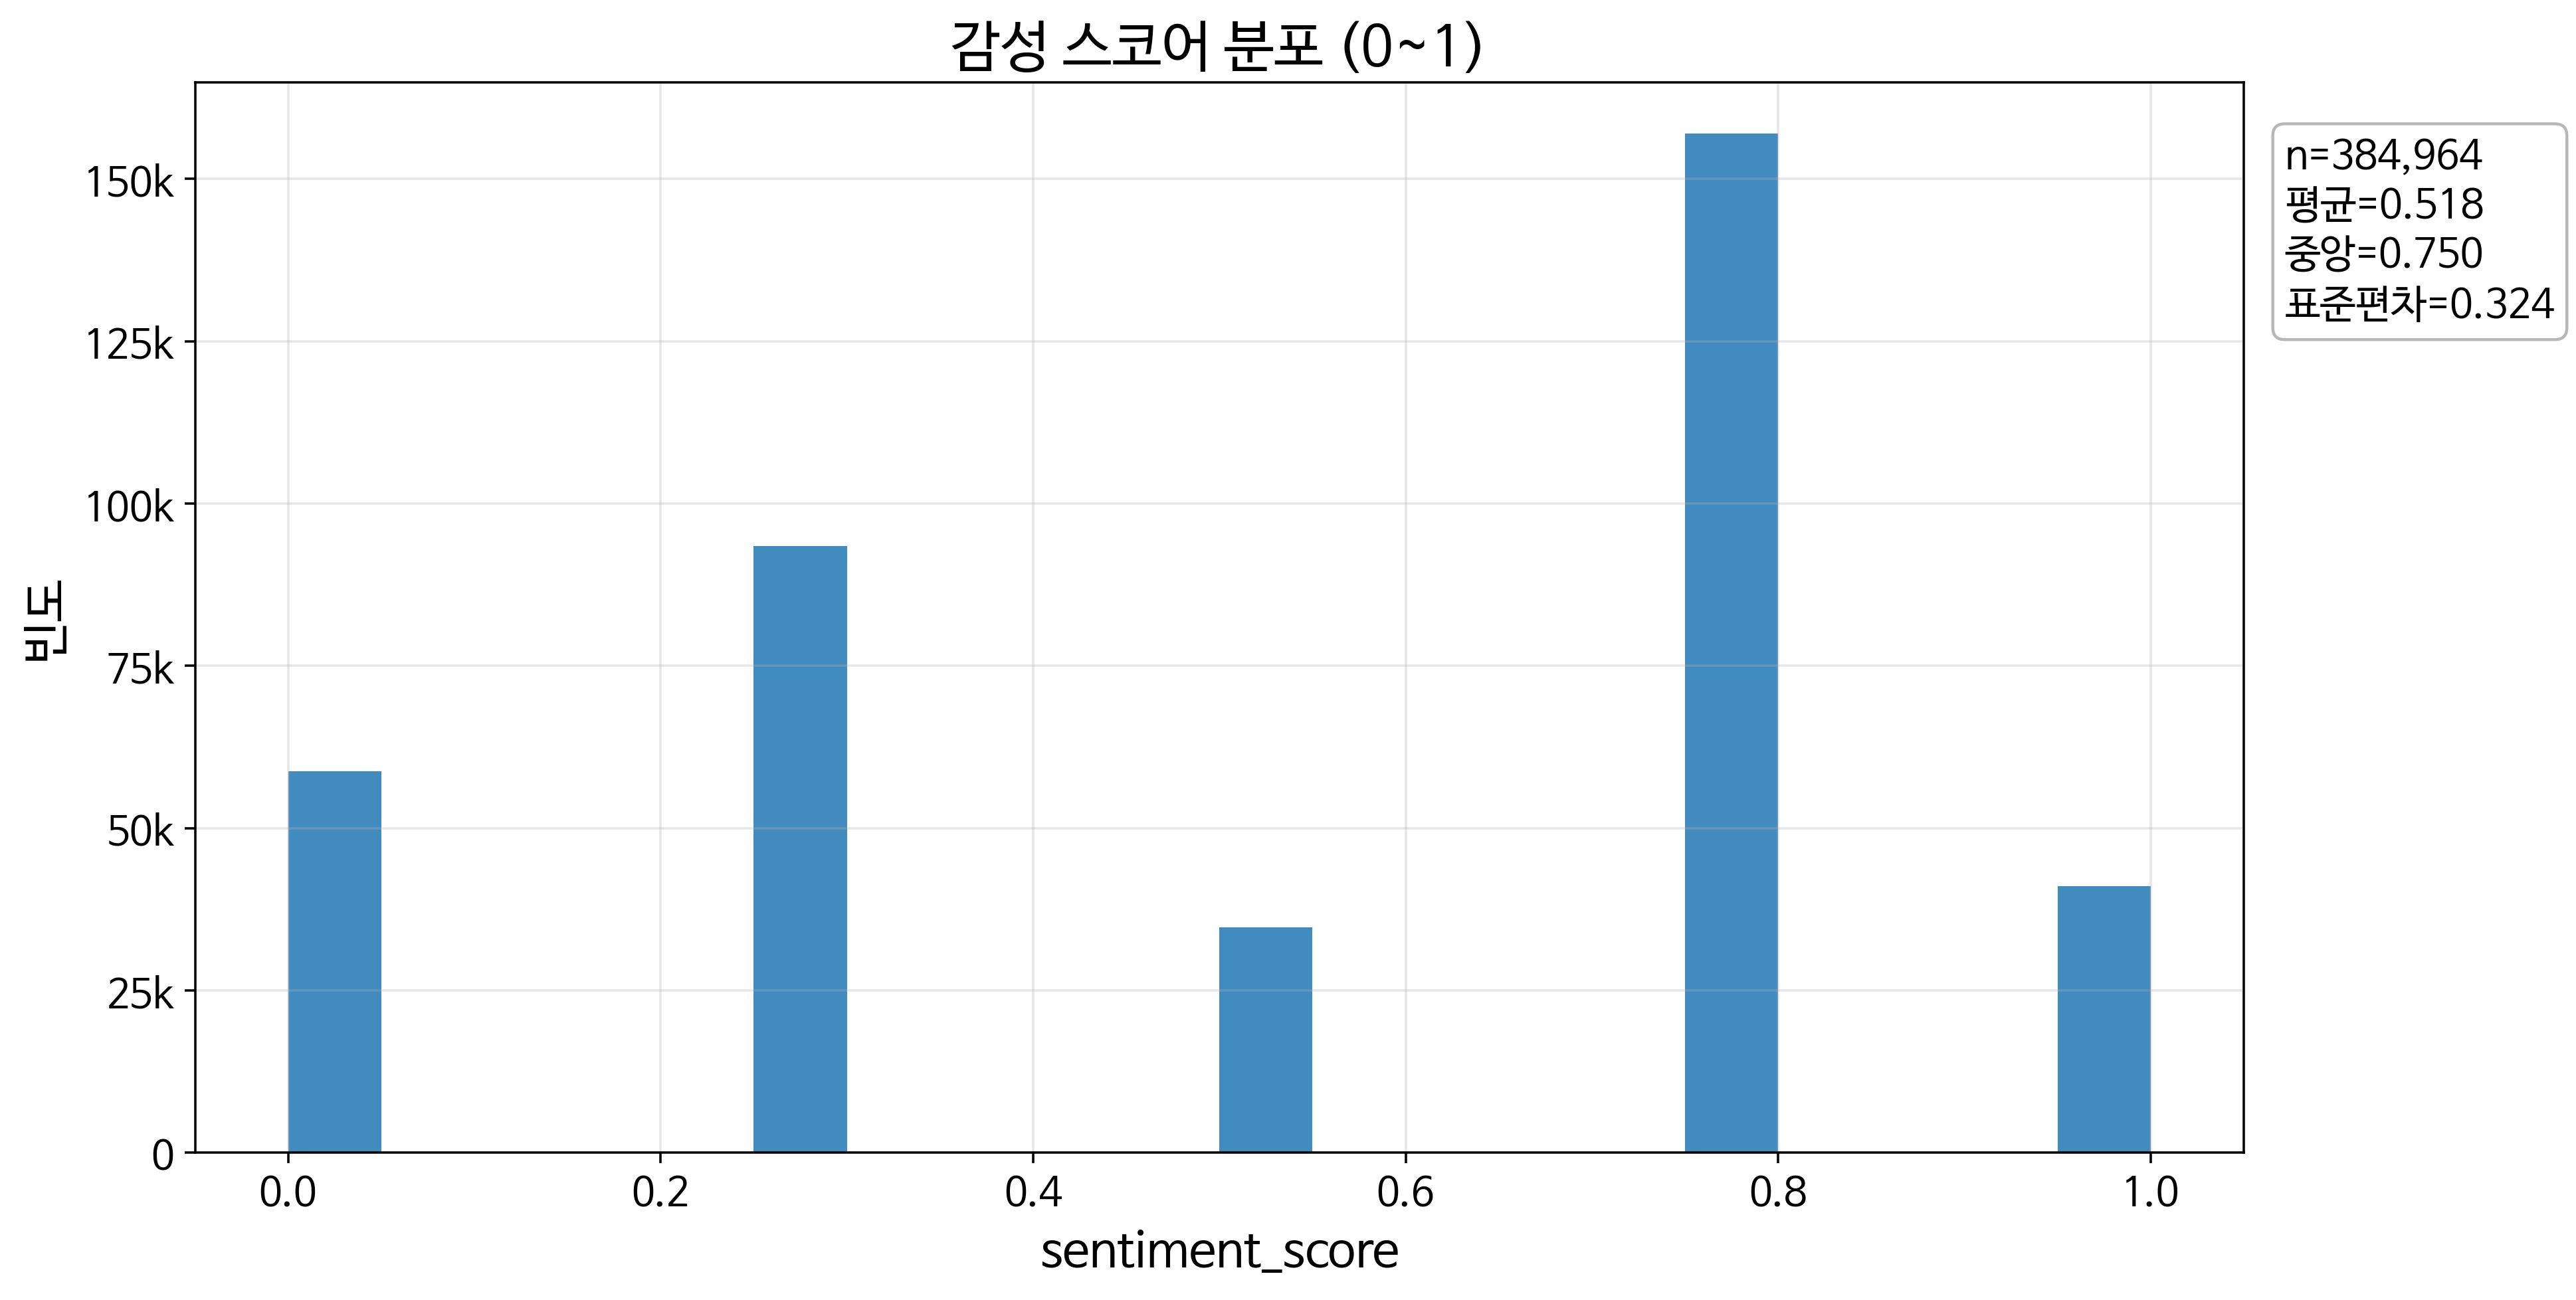

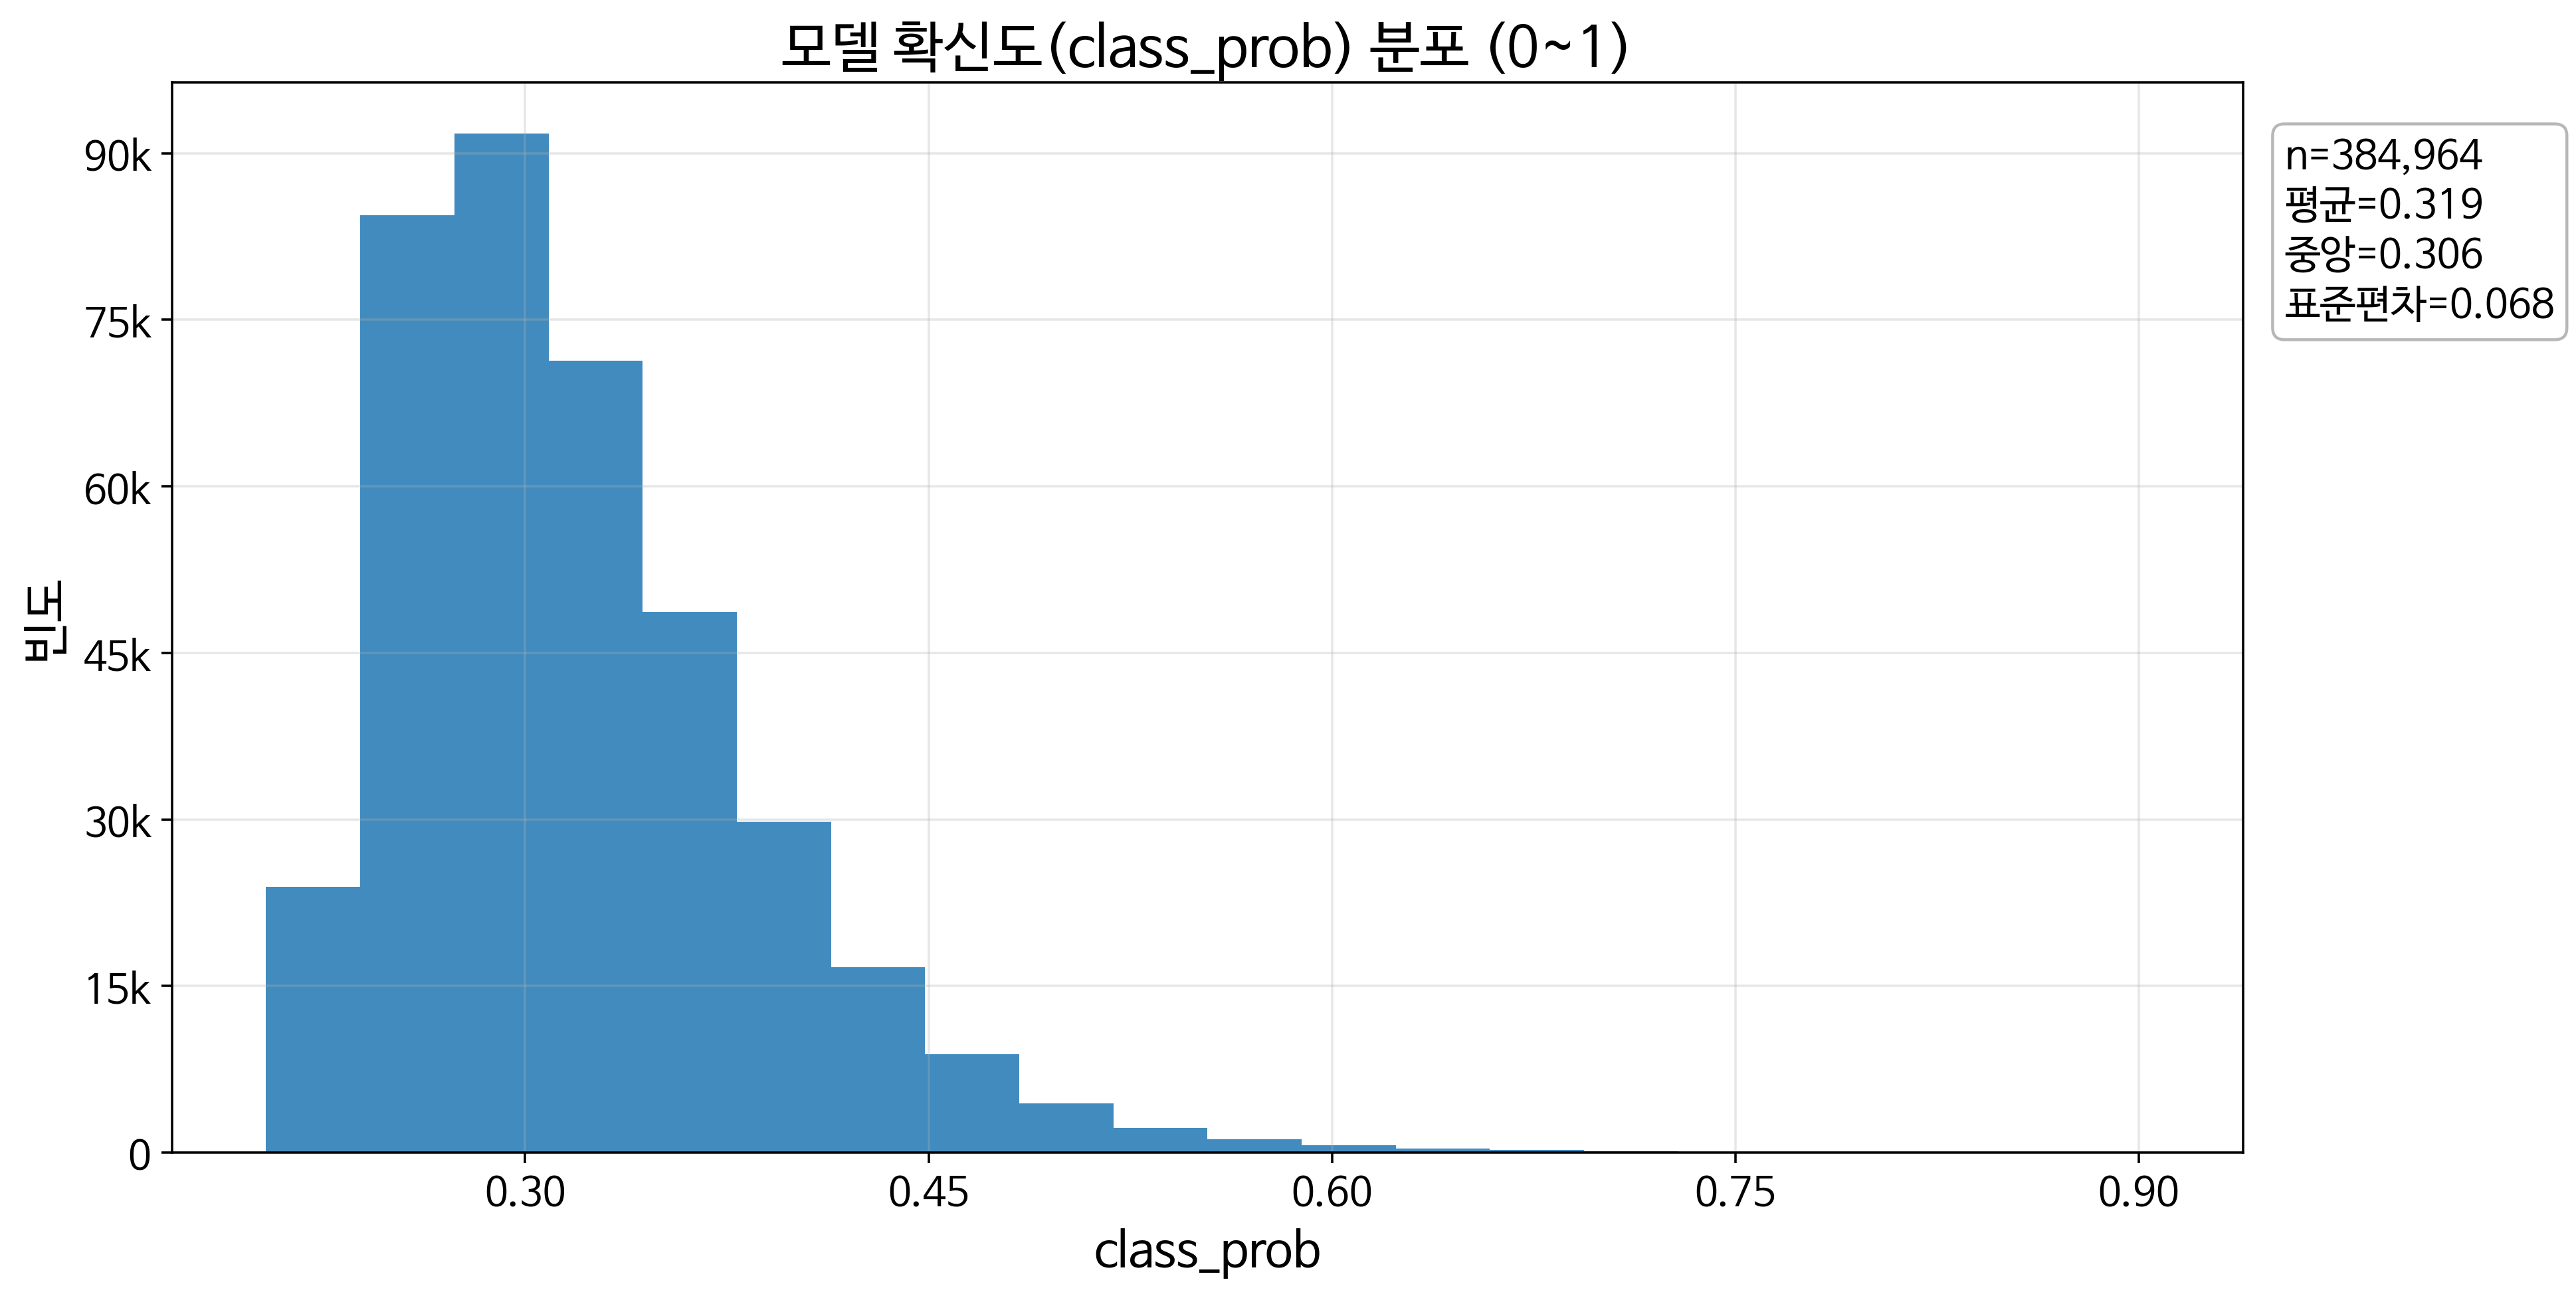

,count,mean,std,min,25%,50%,75%,max,skew,kurt
sentiment_score,384964.0,0.518260,0.324264,0.000000,0.250000,0.750000,0.750000,1.000000,-0.262520,-1.264263
class_prob,384964.0,0.318944,0.067589,0.203669,0.269254,0.305521,0.354325,0.903811,1.289848,2.774686


In [ ]:
# === 2) EDA-1: 분포 점검 (글씨 크게 + 겹침 방지) ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter

def _kfmt(x, pos=None):  # 12000 -> 12k
    x = float(x)
    if x >= 1e6: return f"{x/1e6:.1f}M"
    if x >= 1e3: return f"{x/1e3:.0f}k"
    return f"{int(x)}"

def plot_hist_big_clean(series: pd.Series, title: str, xlabel: str, bins=20,
                        font_scale=1.35, figsize=(12,6), dpi=160):
    s = series.dropna().to_numpy()

    rc = {
        "font.size":       10 * font_scale,
        "axes.titlesize":  14 * font_scale,
        "axes.labelsize":  12 * font_scale,
        "xtick.labelsize": 10 * font_scale,
        "ytick.labelsize": 10 * font_scale,
    }
    with plt.rc_context(rc):
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi, constrained_layout=True)
        ax.hist(s, bins=bins, alpha=0.85)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("빈도")

        # 틱 겹침 방지
        ax.xaxis.set_major_locator(MaxNLocator(7))
        ax.yaxis.set_major_locator(MaxNLocator(7))
        ax.yaxis.set_major_formatter(FuncFormatter(_kfmt))
        ax.grid(True, alpha=0.3)

        # 요약 통계 박스(그래프 바깥 겹침 방지)
        mean, med, std = np.mean(s), np.median(s), np.std(s)
        txt = f"n={len(s):,}\n평균={mean:.3f}\n중앙={med:.3f}\n표준편차={std:.3f}"
        ax.text(1.02, 0.95, txt, ha="left", va="top", transform=ax.transAxes,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.95))
        plt.show()

# 1) 감성 스코어 분포
plot_hist_big_clean(
    ckpt['sentiment_score'],
    title="감성 스코어 분포 (0~1)",
    xlabel="sentiment_score",
    bins=20
)

# 2) 모델 확신도 분포
plot_hist_big_clean(
    ckpt['class_prob'],
    title="모델 확신도(class_prob) 분포 (0~1)",
    xlabel="class_prob",
    bins=20
)

# 3) 간단 요약 통계 + 왜도/첨도 (표는 그대로)
summary = ckpt[['sentiment_score','class_prob']].describe().T
summary['skew'] = ckpt[['sentiment_score','class_prob']].skew()
summary['kurt'] = ckpt[['sentiment_score','class_prob']].kurt()  # pandas: 정상분포=0
summary


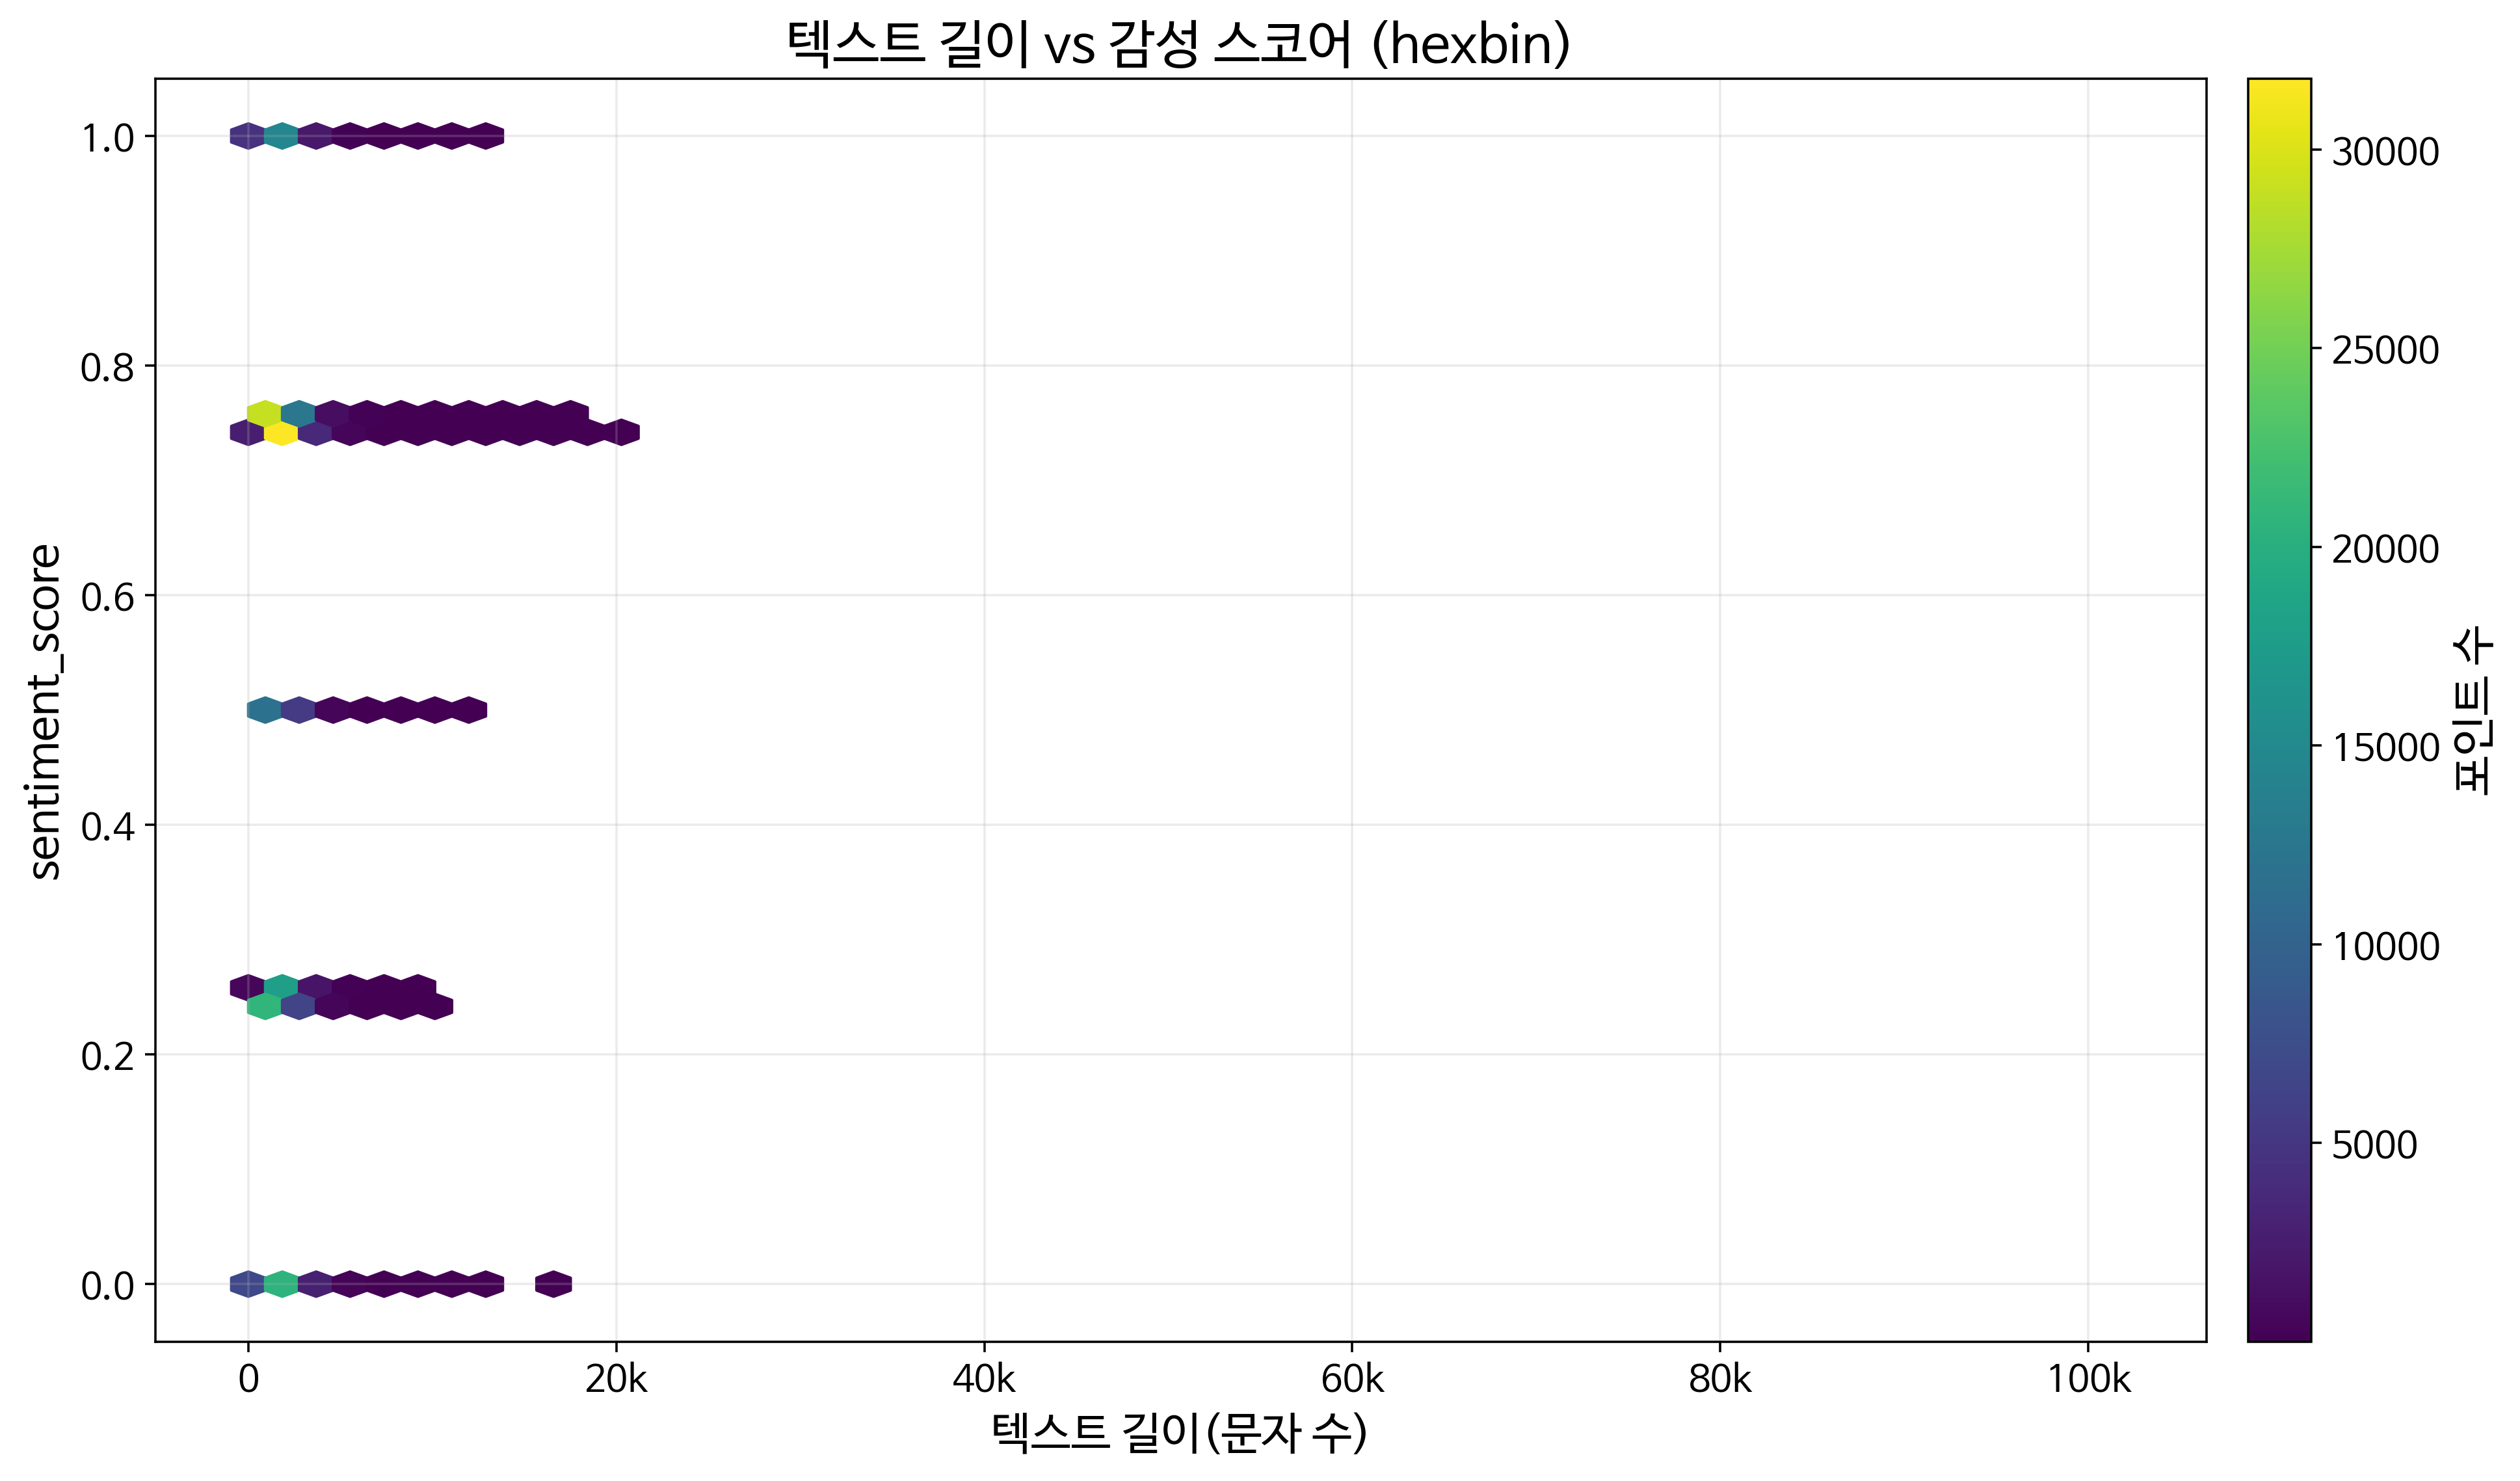

/tmp/ipython-input-1333438037.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = sample.groupby('len_bin')['sentiment_score'] \


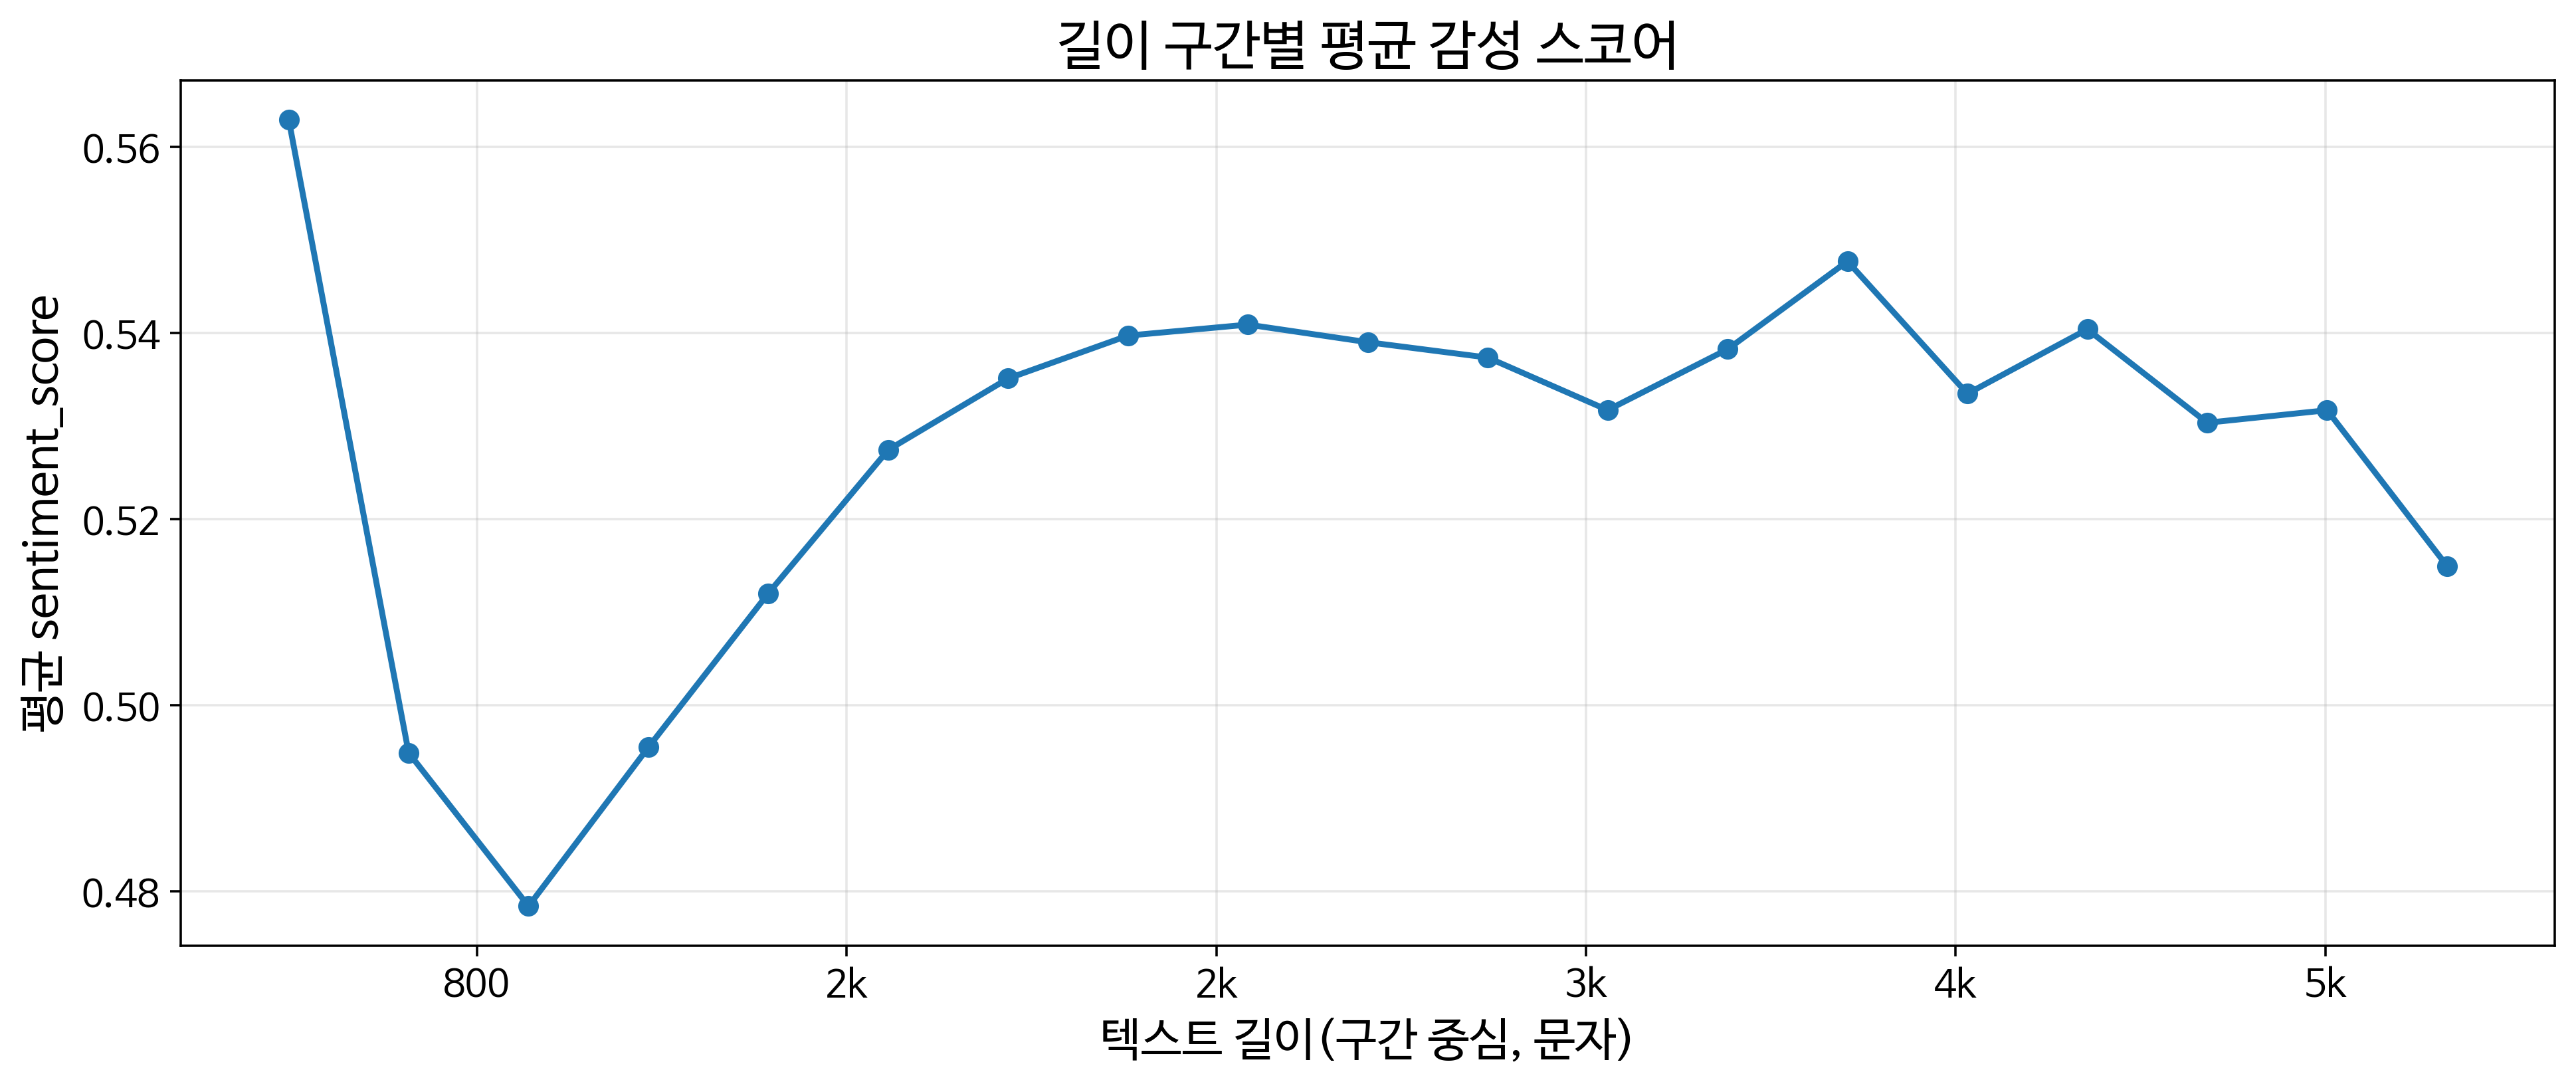

In [ ]:
# ====== EDA-3: 텍스트 길이 vs 감성 (글씨 크게 + 겹침 방지) ======
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter

# (선택) 길이 숫자 보기 좋게: 12000 -> 12k
def _kfmt(x, pos=None):
    x = float(x)
    if x >= 1e6:  return f"{x/1e6:.1f}M"
    if x >= 1e3:  return f"{x/1e3:.0f}k"
    return f"{int(x)}"

# ----------------------------
# 1) 길이-감성 HEXBIN (조밀도)
# ----------------------------
FONT_SCALE = 1.30  # 전체 글씨 스케일
rc = {
    "font.size":          10 * FONT_SCALE,
    "axes.titlesize":     14 * FONT_SCALE,
    "axes.labelsize":     12 * FONT_SCALE,
    "xtick.labelsize":    10 * FONT_SCALE,
    "ytick.labelsize":    10 * FONT_SCALE,
}

with plt.rc_context(rc):
    # len_df는 네 함수(build_review_length_df)로 준비되어 있어야 함
    assert 'len_df' in globals() and not len_df.empty, "len_df가 비었습니다."
    n = min(len(len_df), 200_000)
    sample = len_df.sample(n, random_state=42) if len(len_df) > n else len_df.copy()

    fig, ax = plt.subplots(figsize=(12, 7), dpi=160, constrained_layout=True)
    hb = ax.hexbin(sample['text_len'], sample['sentiment_score'],
                   gridsize=55, mincnt=5)
    cb = fig.colorbar(hb, ax=ax, pad=0.02)
    cb.set_label("포인트 수")

    # 축/라벨(겹침 방지: 틱 개수 제한 + 숫자 포매터)
    ax.set_title("텍스트 길이 vs 감성 스코어 (hexbin)")
    ax.set_xlabel("텍스트 길이(문자 수)")
    ax.set_ylabel("sentiment_score")
    ax.xaxis.set_major_locator(MaxNLocator(6))
    ax.yaxis.set_major_locator(MaxNLocator(6))
    ax.xaxis.set_major_formatter(FuncFormatter(_kfmt))
    ax.grid(alpha=0.25)
    plt.show()

# ------------------------------------------
# 2) 길이 구간별 평균 감성(라인) + 큰 글씨
#    - x축은 구간 중심값(k 단위), 틱 수 제한으로 겹침 방지
# ------------------------------------------
with plt.rc_context(rc):
    # 1%~99% 범위 내에서 균등 구간
    lo = sample['text_len'].quantile(0.01)
    hi = sample['text_len'].quantile(0.99)
    bins = np.linspace(lo, hi, 20)
    sample = sample.copy()
    sample['len_bin'] = pd.cut(sample['text_len'], bins=bins, include_lowest=True)

    agg = sample.groupby('len_bin')['sentiment_score'] \
                .agg(['mean','count','std']).reset_index()

    # 구간 중심값 계산(라벨로 사용)
    centers = 0.5 * (bins[1:] + bins[:-1])

    fig, ax = plt.subplots(figsize=(12, 5), dpi=160, constrained_layout=True)
    ax.plot(centers, agg['mean'].to_numpy(), marker='o', linewidth=2, markersize=6)
    ax.set_title("길이 구간별 평균 감성 스코어")
    ax.set_xlabel("텍스트 길이(구간 중심, 문자)")
    ax.set_ylabel("평균 sentiment_score")

    # 틱 적당히만 노출 + 보기 좋은 숫자
    ax.xaxis.set_major_locator(MaxNLocator(8))
    ax.xaxis.set_major_formatter(FuncFormatter(_kfmt))
    ax.yaxis.set_major_locator(MaxNLocator(6))
    ax.grid(True, alpha=0.3)
    plt.show()
